<h1>ENSO Teleconnections - Precip - ERA5 vs SEAS5</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
from io import BytesIO
from PIL import Image
import scipy
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import oni, timeutil

import warnings
warnings.filterwarnings('ignore')

<h3>User Configurables</h3>

In [3]:
# seas5 sst data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/precip/'

In [4]:
seas5_var = 'tprate'
verif_var = 'total_precipitation_24hr'

In [5]:
time_range = ("1994-01-01", "2020-12-01")
initmonth = 11  # Only get this init within the time_range

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = (1, 2, 3)

In [6]:
# Scale variables for unit-matching
seas5_scaling_factor = 86400000
verif_scaling_factor = 1000

In [7]:
# Define a region over which to calculate correlation
# You can ignore region by setting it to None
# region = None
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax': 240.0
}

In [8]:
# Filter ONI events per specific criteria.
strength = None  # For example, you can set strength = 'Weak', 'Moderate', 'Strong', or 'Very Strong'
oni_threshold = None  # For example, you can set oni_threshold = 3

In [9]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>El Niño Events</h3>

In [10]:
oni.elnino_events  # These have been prerecorded

((1951, 1.2),
 (1952, 0.8),
 (1953, 0.8),
 (1957, 1.8),
 (1958, 0.6),
 (1963, 1.4),
 (1965, 1.9),
 (1968, 1.1),
 (1969, 0.9),
 (1972, 1.8),
 (1976, 0.9),
 (1977, 0.8),
 (1979, 0.6),
 (1982, 2.2),
 (1986, 1.2),
 (1987, 1.7),
 (1991, 1.7),
 (1994, 1.1),
 (1997, 2.4),
 (2002, 1.3),
 (2004, 0.7),
 (2006, 0.94),
 (2009, 1.36),
 (2014, 0.93),
 (2015, 2.64),
 (2018, 0.9),
 (2023, 1.95))

<h3>La Niña Events</h3>

In [11]:
oni.lanina_events  # These have been prerecorded

((1954, -0.9),
 (1955, -1.4),
 (1964, -0.8),
 (1970, -1.4),
 (1971, -0.9),
 (1973, -1.9),
 (1974, -0.8),
 (1975, -1.7),
 (1983, -0.9),
 (1984, -0.9),
 (1988, -1.8),
 (1995, -1.0),
 (1998, -1.6),
 (1999, -1.7),
 (2000, -0.7),
 (2005, -0.85),
 (2007, -1.64),
 (2008, -0.85),
 (2010, -1.64),
 (2011, -1.09),
 (2016, -0.69),
 (2017, -0.97),
 (2020, -1.27),
 (2021, -1.06),
 (2022, -0.99))

<h3>Create ONI objects for each event</h3>

In [12]:
ElNinos = [oni.ONI(event[0], event[1]) for event in oni.elnino_events]
LaNinas = [oni.ONI(event[0], event[1]) for event in oni.lanina_events]

In [13]:
elnino_strengths = [nino.get('strength') for nino in ElNinos]
lanina_strengths = [nina.get('strength') for nina in LaNinas]

In [14]:
collections.Counter(elnino_strengths)

Counter({'Weak': 11, 'Moderate': 7, 'Strong': 6, 'Very Strong': 3})

In [15]:
collections.Counter(lanina_strengths)

Counter({'Weak': 12, 'Strong': 7, 'Moderate': 6})

<h3>Get El Niño / La Niña years per specific criteria</h3>

In [16]:
# El Nino years
elnino_years = []
for nino in ElNinos:
    if strength is not None and nino.get('strength') != strength:
        continue      
    if oni_threshold is not None and nino.get('oni_magnitude') < oni_threshold:
        continue     
    elnino_years.append(nino.get('year'))

# La Nina
lanina_years = []
for nina in LaNinas:
    if strength is not None and nina.get('strength') != strength:
        continue      
    if oni_threshold is not None and nina.get('oni_magnitude') < oni_threshold:
        continue     
    lanina_years.append(nina.get('year'))
    
# Print El Nino years
print("Number of El Nino years: ", len(elnino_years))
for this_year in elnino_years:
    print(this_year, end=' ')
    
print('\n')

# Print La Nina years
print("Number of La Nina years: ", len(lanina_years))
for this_year in lanina_years:
    print(this_year, end=' ')
    

Number of El Nino years:  27
1951 1952 1953 1957 1958 1963 1965 1968 1969 1972 1976 1977 1979 1982 1986 1987 1991 1994 1997 2002 2004 2006 2009 2014 2015 2018 2023 

Number of La Nina years:  25
1954 1955 1964 1970 1971 1973 1974 1975 1983 1984 1988 1995 1998 1999 2000 2005 2007 2008 2010 2011 2016 2017 2020 2021 2022 

In [17]:
# Our model data doesn't go back to year 1950, nor does it reach the present, so what years are remaining?

begin_year = int(time_range[0][0:4])
end_year = int(time_range[1][0:4])

# print(begin_year)
# print(end_year)
# print('')

elnino_years_in_data = [y for y in elnino_years if y >= begin_year and y <= end_year]
lanina_years_in_data = [y for y in lanina_years if y >= begin_year and y <= end_year]

print('El Nino in data:')
print(elnino_years_in_data)
print('')
print('La Nina in data:')
print(lanina_years_in_data)

El Nino in data:
[1994, 1997, 2002, 2004, 2006, 2009, 2014, 2015, 2018]

La Nina in data:
[1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2016, 2017, 2020]


<h3>Read in datasets and do some preprocessing</h3>

In [18]:
# 1 indicator shall refer to VERIF data
data_reader1 = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [19]:
# 2 indicator shall refer to SEAS5 data
# Our Regridder requires 1 UFS-type data reader.
# What we will do is instantiate a UFS data reader,
# but then supplant its data with the SEAS5 dataset.
data_reader2 = dr.getDataReader(datasource='UFS',                  
                                experiment = 'baseline',
                                # filename=f'experiments/phase_1/{ufs_experiment}/atm_monthly.zarr',                     
                                model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [20]:
# Collect all sst seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [21]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [22]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
data_reader2.update(ds=seas5_ds) 

Dataset updated.


In [23]:
ds1 = data_reader1.retrieve(var=verif_var)

In [24]:
ds2 = data_reader2.retrieve(var=seas5_var,
                            time=time_range,
                            initmonths=initmonth,
                            lead=(min(leads), max(leads)),
                            member=(0, 24), # We know seas5 hindcast has members 0-24
                            ens_avg=True)

Taking Ensemble Average


In [25]:
# Ensure that temporal domains perfectly match.
ds1 = timeutil.match_time_to_leads(verif_ds=ds1,
                                   ufs_ds=ds2)

In [26]:
# Scale fields.
ds1 = ds1 * verif_scaling_factor                                                                          
ds2 = ds2 * seas5_scaling_factor

In [27]:
# Update datareaders with subsetted and scaled data.
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h5>Instantiate Regridder</h5>

In [28]:
regridder = Regrid.Regrid(data_reader1=data_reader1,                                                              
                          data_reader2=data_reader2,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
data_reader1 must be temporally resampled before spatially regridding.
Resample these data by running <RegridObj>.resample(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for resample, run <RegridObj>.resample_vars()

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (ERA5_DataReader): lat 256, lon 512
Output grid shape data_reader2 (UFS_DataReader): lat 180, lon 360
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
data_reader1 can have its time coordinates converted to init+lead.
Lead resolution of the UFS dataset interpreted as monthly intervals.
Align these data by running <RegridObj>.align() (You may need to resample and/or regrid first.)



In [29]:
# Get u-v fields for the highest resolution grid.
vars_to_resample = verif_var
vars_to_regrid = list(globals()[f'data_reader{regridder.highres_grid}'].dataset().keys())
print(f'will resample {vars_to_resample}')
print(f'will regrid {vars_to_regrid}')

will resample total_precipitation_24hr
will regrid ['total_precipitation_24hr']


In [30]:
# RESAMPLE.  (Give this a few minutes to complete.)
regridder.resample(var=vars_to_resample)

Resampling data_reader1 data to 'MS' using mean aggregation.
Resampling from 1994-11-01T00 to 2021-02-28T18
Number of cores available: 12
Finished multiprocessing.  Concatenating results.
Resample completed in 0.52 minutes.
Resample results stored in <RegridObj>.resampled


In [31]:
# REGRID.
regridder.regrid(var=vars_to_regrid)

Regridding data_reader1 grid (ERA5_DataReader) onto data_reader2 grid (UFS_DataReader)
Running scalar regrid on total_precipitation_24hr
Completed scalar regrid in 0.03 minutes.
Regrid results stored in <RegridObj>.regridded


In [32]:
# ALIGN.
regridder.align()

Aligning time coordinate to init+lead coordinates.
MODEL_LEADS: [1 2 3]
Time dimensions aligned:  matched 81 timesteps
Align results stored in <RegridObj>.aligned


In [33]:
# Datasets have been pre-processed.
# Need some logic here to extract the results.

# For these notebooks, we know that Verif data are aligned:
ds1 = regridder.aligned.dataset()

# SEAS5 data could be in the regridded slot or not, depending on the experiment we're working with.
if regridder.highres_grid == 2:
    ds2 = regridder.regridded.dataset()
else:
    ds2 = data_reader2.dataset()

In [34]:
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h3>Ready for ONI calculations!</h3>

In [35]:
ds1_elnino_statistics, ds1_lanina_statistics, ds2_elnino_statistics, ds2_lanina_statistics =\
oni.prep_oni_datasets(data_reader1  = data_reader1,
                      var1          = verif_var,
                      data_reader2  = data_reader2,
                      var2          = seas5_var,
                      statistics    = ['anomaly'],
                      elnino_years  = elnino_years,
                      lanina_years  = lanina_years)

Calculating climatology statistics and anomalies.
ONI Datasets Ready.


<p>
---------------------------------------------------------------<br>
We now have 4 datasets of statistics:<br>
<br>
ds1_elnino_statistics<br>
ds1_lanina_statistics<br>
ds2_elnino_statistics<br>
ds2_lanina_statistics<br>
---------------------------------------------------------------
</p>

<h3>Run t-tests</h3>

In [36]:
# Get position of init and lead axes
dims = list(ds1_elnino_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [37]:
# EL NINO
anomaly_tstatistic_elnino, anomaly_pvalue_elnino =\
    scipy.stats.ttest_ind(a=ds1_elnino_statistics['anomaly'].values,
                          b=ds2_elnino_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# LA NINA
anomaly_tstatistic_lanina, anomaly_pvalue_lanina =\
    scipy.stats.ttest_ind(a=ds1_lanina_statistics['anomaly'].values,
                          b=ds2_lanina_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [38]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_elnino': (('lat', 'lon'), anomaly_pvalue_elnino),
        'anomaly_pvalue_lanina': (('lat', 'lon'), anomaly_pvalue_lanina)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h1>Anomaly</h1>

In [39]:
# This is the DataArray for the Composite
ds1_elnino_composite = ds1_elnino_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_lanina_composite = ds1_lanina_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_elnino_composite = ds2_elnino_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_lanina_composite = ds2_lanina_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
elnino_ds2_minus_ds1 = ds2_elnino_composite - ds1_elnino_composite
lanina_ds2_minus_ds1 = ds2_lanina_composite - ds1_lanina_composite

# Calculate Correlations
elnino_corr = xr.corr(ds1_elnino_composite, ds2_elnino_composite).values.item()
lanina_corr = xr.corr(ds1_lanina_composite, ds2_lanina_composite).values.item()

# Calculate Correlations over a smaller region
if region is not None:
    
    # latitudes are ordered 90 to -90
    lat_slice = slice(region['latmax'], region['latmin'])
    lon_slice = slice(region['lonmin'], region['lonmax'])
    
    elnino_corr_region = xr.corr(ds1_elnino_composite.sel(lat=lat_slice, lon=lon_slice),
                                 ds2_elnino_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()
    
    lanina_corr_region = xr.corr(ds1_lanina_composite.sel(lat=lat_slice, lon=lon_slice),
                                 ds2_lanina_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()

<h5>Make labels for the plots</h5>

In [40]:
elnino_event_years = list(ds1_elnino_statistics.groupby('init.year').groups.keys())
lanina_event_years = list(ds1_lanina_statistics.groupby('init.year').groups.keys())

# Convert every year into 'YY for compactness.
elnino_event_years = [f"'{str(y)[2:4]}" for y in elnino_event_years]
lanina_event_years = [f"'{str(y)[2:4]}" for y in lanina_event_years]

elnino_event_years = f"Events: {' '.join([f'{y}' for y in elnino_event_years])}"  # convert to string
lanina_event_years = f"Events: {' '.join([f'{y}' for y in lanina_event_years])}"  # convert to string

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
elnino_corr_label = f'corr: {elnino_corr:.2f}'
lanina_corr_label = f'corr: {lanina_corr:.2f}'

if region is not None:
    elnino_corr_label = f'{elnino_corr_label}\nregion: {elnino_corr_region:.2f}'
    lanina_corr_label = f'{lanina_corr_label}\nregion: {lanina_corr_region:.2f}'

<h3>Generate figures</h3>

In [41]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'mm day-1',
               'cmap': 'BrBG',
               'topleft_label': initlead_label, 
               'region': region,
               'dpi': 200}

plot1 = oni.plot_composite(da = ds1_elnino_composite,
                           title=f'{data_reader1.datasource} Precipitation Anomaly (El Nino)',
                           vmin=-6, vmax=6,
                           subtitle=elnino_event_years, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = oni.plot_composite(da = ds1_lanina_composite,
                           title=f'{data_reader1.datasource} Precipitation Anomaly (La Nina)',
                           vmin=-6, vmax=6,
                           subtitle=lanina_event_years, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = oni.plot_composite(da = ds2_elnino_composite,
                           title=f'SEAS5 Precipitation Anomaly (El Nino)',
                           vmin=-6, vmax=6,
                           subtitle=elnino_event_years, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = oni.plot_composite(da = ds2_lanina_composite,
                           title=f'SEAS5 Precipitation Anomaly (La Nina)',
                           vmin=-6, vmax=6,
                           subtitle=lanina_event_years, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = oni.plot_composite(da = elnino_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_elnino'],
                           shading_threshold = 0.05,
                           title=f'SEAS5 minus {data_reader1.datasource} Precipitation Anomaly (El Nino)',
                           vmin=-4, vmax=4,
                           subtitle=elnino_event_years,
                           bottomright_label=elnino_corr_label,
                           **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = oni.plot_composite(da = lanina_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_lanina'],
                           shading_threshold = 0.05,
                           title=f'SEAS5 minus {data_reader1.datasource} Precipitation Anomaly (La Nina)',
                           vmin=-4, vmax=4,
                           subtitle=lanina_event_years,
                           bottomright_label=lanina_corr_label,
                           **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------


<h3>Construct 3 row x 2 column multi-paneled image</h3>

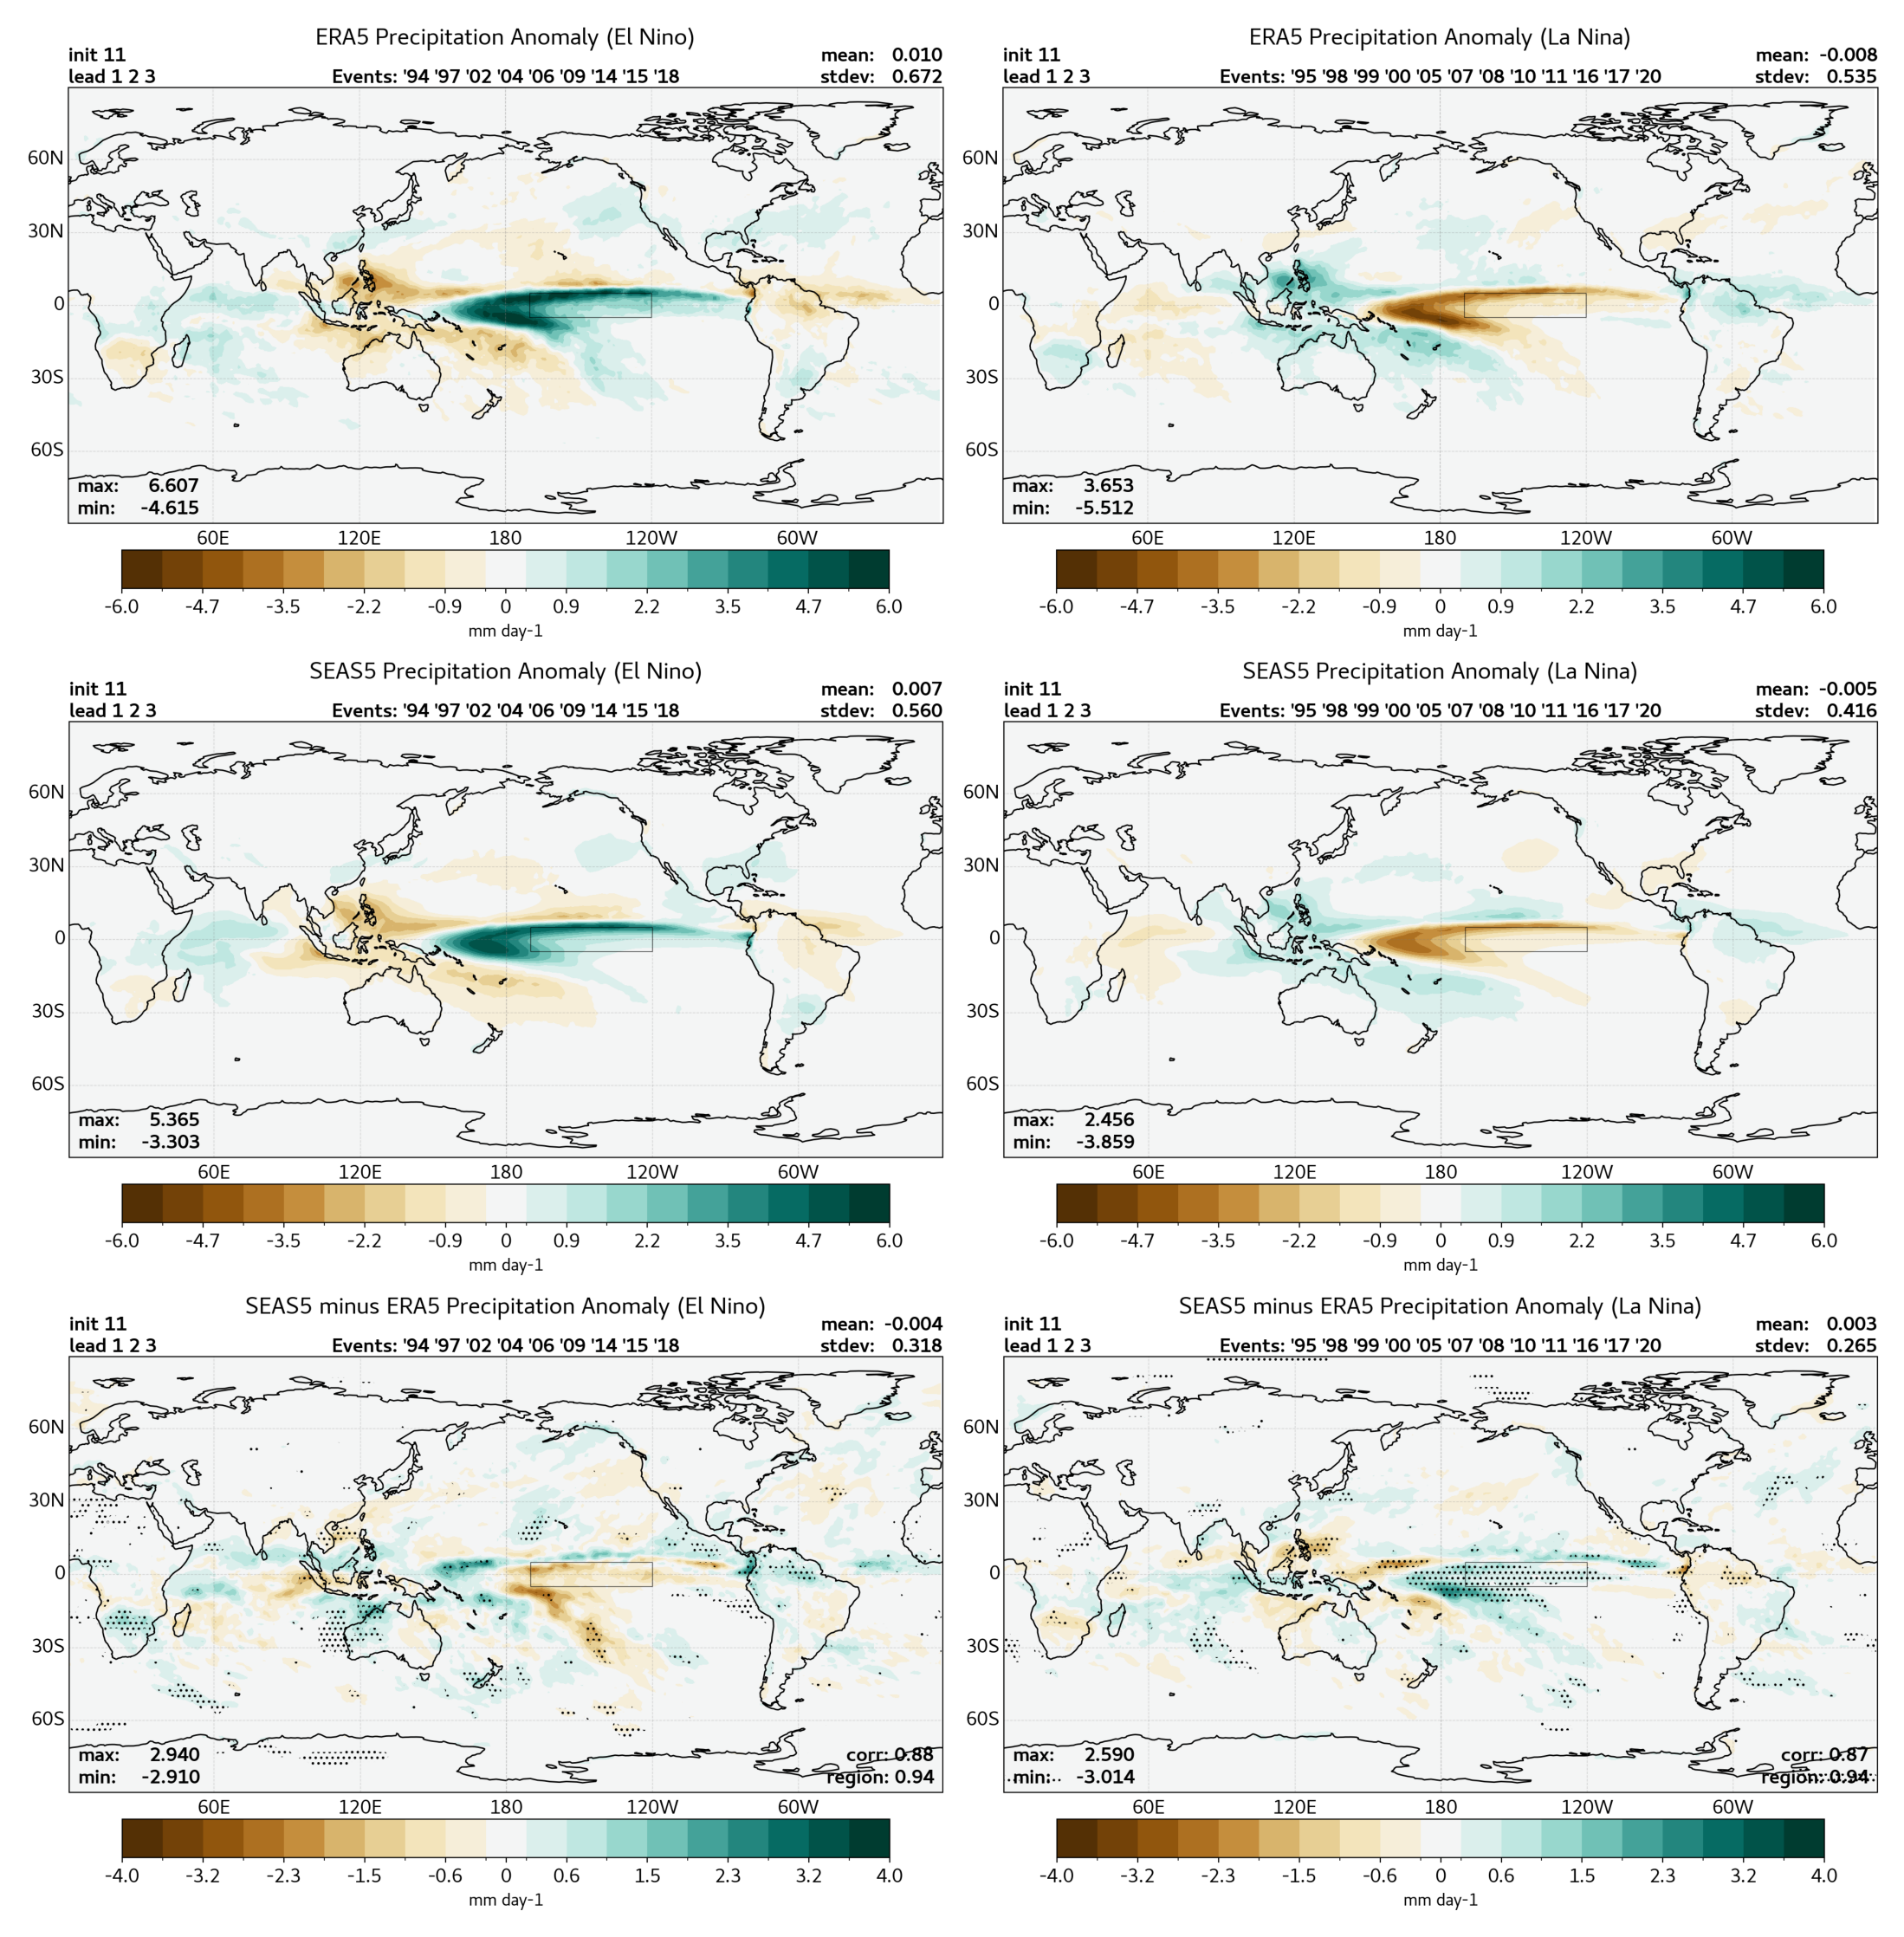

In [42]:
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axs[0, 0].imshow(image1)
axs[0, 0].axis('off')

axs[0, 1].imshow(image2)
axs[0, 1].axis('off')

axs[1, 0].imshow(image3)
axs[1, 0].axis('off')

axs[1, 1].imshow(image4)
axs[1, 1].axis('off')

axs[2, 0].imshow(image5)
axs[2, 0].axis('off')

axs[2, 1].imshow(image6)
axs[2, 1].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=.05)
plt.show()

In [43]:
del buffer1, buffer2, buffer3, buffer4, buffer5, buffer6
del image1, image2, image3, image4, image5, image6
del plot1, plot2, plot3, plot4, plot5, plot6, plt
gc.collect()

37739